In [1]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_14953/3880315484.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, combine='by_coords')


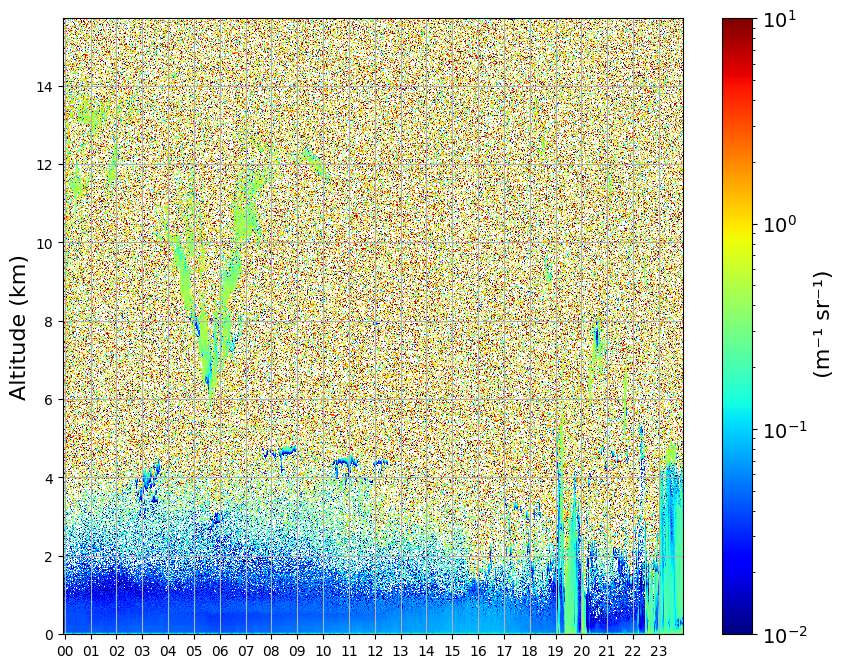

In [ ]:
for date in ['01']:
    folderPath = "01/*.nc"
    data_files = sorted(glob.glob(folderPath, recursive=True))
    ds = xr.open_mfdataset(data_files, combine='by_coords')

    beta_att = ds['linear_depol_ratio'].values  #beta_att, p_pol, x_pol, linear_depol_ratio
    time = ds['time'].values
    altitude = ds['range'].values / 1000  # Altitude in km

    # Create plot (high-resolution)
    plt.figure(figsize=(10, 8))
    # positive_beta_att = beta_att[beta_att > 0]
    # vmin = np.nanpercentile(positive_beta_att, 1)
    # vmax = np.nanpercentile(positive_beta_att, 99)

    # Plot with Logarithmic scale explicitly between 1e-7 and 1e-5
    plt.pcolormesh(
        time, altitude, beta_att.T,
        shading='auto',
        cmap='jet',
        norm=LogNorm(vmin=1e-2, vmax=1e1)
    )
    # norm=Normalize(vmin=0.0, vmax=0.25) # Use this for plotting the depolarization ratio
    

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    # ax.set_ylim(0, 6)  # Limit altitude to 6 km

    # Add colorbar
    cbar = plt.colorbar(label='(m⁻¹ sr⁻¹)')
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(' (m⁻¹ sr⁻¹)', fontsize=16)
    # plt.ylim(0, 6)

    plt.ylabel('Altitude (km)', fontsize=16)
    plt.grid(True)
    plt.savefig(f'linearDepolarization_{date}_test1.png', bbox_inches='tight', dpi=300)
    break

In [13]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from scipy.ndimage import median_filter, gaussian_filter

for date in ['01']:

    folderPath = "01/*.nc"
    data_files = sorted(glob.glob(folderPath))

    ds = xr.open_mfdataset(data_files, combine='by_coords')

    beta_att = ds['linear_depol_ratio'].values
    time = ds['time'].values
    altitude = ds['range'].values / 1000   # km

    # -------------------------------------------------------
    # 1. Remove invalid values
    # -------------------------------------------------------
    beta_att = np.where(beta_att <= 0, np.nan, beta_att)

    # -------------------------------------------------------
    # 2. Smooth data (reduces noise)
    # median filter removes spikes
    # gaussian filter smooths gradients
    # -------------------------------------------------------
    beta_smooth = median_filter(beta_att, size=(3,3))
    beta_smooth = gaussian_filter(beta_smooth, sigma=(1,1))

    # -------------------------------------------------------
    # 3. Automatically determine color scale
    # Use only valid positive values
    # -------------------------------------------------------
    valid = beta_smooth[np.isfinite(beta_smooth)]

    vmin = np.nanpercentile(valid, 2)
    vmax = np.nanpercentile(valid, 98)

    # Ensure valid LogNorm
    vmin = max(vmin, 1e-6)
    vmax = max(vmax, vmin*10)

    norm = LogNorm(vmin=vmin, vmax=vmax)

    # -------------------------------------------------------
    # 4. Plot
    # -------------------------------------------------------
    plt.figure(figsize=(10,8))

    plt.pcolormesh(
        time,
        altitude,
        beta_smooth.T,
        shading='auto',
        cmap='turbo',   # better than jet
        norm=norm
    )

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

    plt.ylabel('Altitude (km)', fontsize=16)
    plt.grid(True)

    cbar = plt.colorbar()
    cbar.set_label('(m⁻¹ sr⁻¹)', fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    plt.savefig(
        f'linearDepolarization_{date}_smooth.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_14953/2641046421.py:14: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, combine='by_coords')


In [8]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from scipy.ndimage import median_filter, gaussian_filter
from scipy.stats import gaussian_kde

for date in ['01']:

    folderPath = "01/*.nc"
    data_files = sorted(glob.glob(folderPath))

    ds = xr.open_mfdataset(data_files, combine='by_coords')

    beta_att = ds['linear_depol_ratio'].values
    time = ds['time'].values
    altitude = ds['range'].values / 1000   # km    
    beta_att = ds['linear_depol_ratio'].values
    np.save(f'linear_depol_ratio_{date}.npy', beta_att)


    # beta_att = np.where(beta_att <= 0, np.nan, beta_att)

    # beta_smooth = median_filter(beta_att, size=(3,3))
    # beta_smooth = gaussian_filter(beta_smooth, sigma=(1,1))

    # valid = beta_smooth[np.isfinite(beta_smooth)]

    # # -------------------------------------------------------
    # # Distribution plot (KDE)
    # # -------------------------------------------------------
    # plt.figure(figsize=(8, 4))
    # plt.hist(valid, bins=100)
    # plt.xlabel('Linear Depolarization Ratio')
    # plt.ylabel('Count')
    # plt.savefig(f'linearDepolarization_{date}_hist.png', dpi=300, bbox_inches='tight')
    # plt.close()


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3657/593787270.py:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, combine='by_coords')


In [6]:
print(beta_att.shape)
n_negative = np.sum(beta_att <= 0)
n_nan = np.sum(np.isnan(beta_att))
print(f"Values <= 0: {n_negative}")
print(f"NaN values: {n_nan}")
beta_att = np.where(beta_att <= 0, np.nan, beta_att)
print(beta_att.shape)

(1440, 3276)
Values <= 0: 2024110
NaN values: 0
(1440, 3276)


In [ ]:
beta_att = np.where(beta_att <= 0, np.nan, beta_att)
beta_smooth = median_filter(beta_att, size=(3,3))
beta_smooth = gaussian_filter(beta_smooth, sigma=(1,1))
valid = beta_smooth[np.isfinite(beta_smooth)]


plt.figure(figsize=(10,8))

plt.pcolormesh(
    time,
    altitude,
    beta_smooth.T
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

plt.ylabel('Altitude (km)', fontsize=16)
plt.grid(True)

cbar = plt.colorbar()
cbar.set_label('(m⁻¹ sr⁻¹)', fontsize=16)
cbar.ax.tick_params(labelsize=14)
plt.show()

# plt.savefig(f'linearDepolarization_{date}_smooth.png',dpi=300,bbox_inches='tight')

# plt.close()